C:\Users\Hp\AppData\Local\Temp\ipykernel_10320\2823399239.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dates'] = pd.to_datetime(df['Dates'])


Total Contract Value: $1880702.22


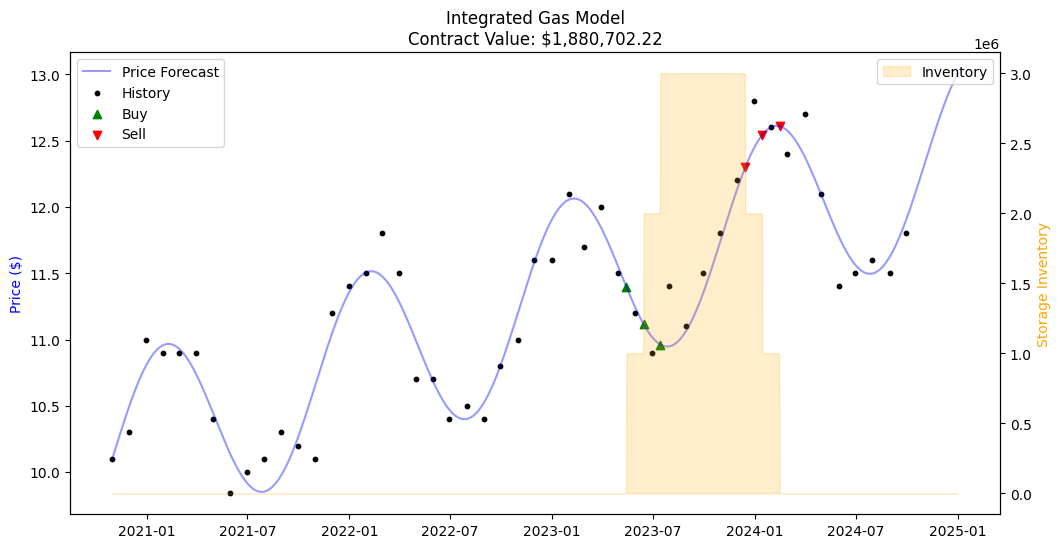

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from datetime import datetime

# ---------------------------------------------------------
# 1. PRICE PREDICTION MODEL (Trend + Seasonality)
# ---------------------------------------------------------

# Load and prepare historical data
df = pd.read_csv('Nat_Gas.csv')
df['Dates'] = pd.to_datetime(df['Dates'])
start_date = df['Dates'].min()
df['Days'] = (df['Dates'] - start_date).dt.days

def model_func(t, A, B, C, D):
    """Linear trend + Sine wave for seasonality."""
    return A * t + B + C * np.sin(2 * np.pi * t / 365.25 + D)

# Fit the parameters A, B, C, D using historical data
params, _ = curve_fit(model_func, df['Days'], df['Prices'], p0=[0.001, 10, 1, 0])

def get_price(input_date):
    """Estimate price for any date using the model."""
    if isinstance(input_date, str):
        input_date = pd.to_datetime(input_date)
    days = (input_date - start_date).days
    return model_func(days, *params)

# ---------------------------------------------------------
# 2. CONTRACT PRICING FUNCTION
# ---------------------------------------------------------

def price_contract(injection_dates, withdrawal_dates, injection_rate, 
                   withdrawal_rate, max_volume, storage_cost_per_month):
    """
    Simulates cash flows and returns the total value of the contract.
    """
    total_value = 0
    current_inventory = 0
    events = []
    for d in injection_dates: events.append({'date': pd.to_datetime(d), 'type': 'inj'})
    for d in withdrawal_dates: events.append({'date': pd.to_datetime(d), 'type': 'with'})
    events.sort(key=lambda x: x['date'])
    
    last_date = events[0]['date']
    log = []

    for event in events:
        date, price = event['date'], get_price(event['date'])
        
        # Deduct storage cost since last activity
        months = (date.year - last_date.year) * 12 + (date.month - last_date.month)
        total_value -= (months * storage_cost_per_month * current_inventory)
        
        if event['type'] == 'inj':
            amount = min(injection_rate, max_volume - current_inventory)
            total_value -= (amount * price)
            current_inventory += amount
        else:
            amount = min(withdrawal_rate, current_inventory)
            total_value += (amount * price)
            current_inventory -= amount
            
        log.append({'Date': date, 'Inventory': current_inventory})
        last_date = date

    return round(total_value, 2), log

# ---------------------------------------------------------
# 3. RUN SIMULATION & VISUALIZE
# ---------------------------------------------------------

# Inputs for testing
inj_dates = ['2023-05-15', '2023-06-15', '2023-07-15']
with_dates = ['2023-12-15', '2024-01-15', '2024-02-15']
max_v, rate, s_cost = 5000000, 1000000, 0.1

contract_val, log_data = price_contract(inj_dates, with_dates, rate, rate, max_v, s_cost)

# Prepare Visualization
vis_dates = pd.date_range(df['Dates'].min(), pd.to_datetime('2025-01-01'), freq='D')
vis_prices = [get_price(d) for d in vis_dates]
inv_status = pd.Series(0.0, index=vis_dates)
for entry in log_data: inv_status.loc[entry['Date']:] = entry['Inventory']

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(vis_dates, vis_prices, color='blue', alpha=0.4, label='Price Forecast')
ax1.scatter(df['Dates'], df['Prices'], color='black', s=10, label='History')
ax1.set_ylabel('Price ($)', color='blue')

# Show injections and withdrawals
ax1.scatter(pd.to_datetime(inj_dates), [get_price(d) for d in inj_dates], color='green', marker='^', label='Buy')
ax1.scatter(pd.to_datetime(with_dates), [get_price(d) for d in with_dates], color='red', marker='v', label='Sell')

ax2 = ax1.twinx()
ax2.fill_between(vis_dates, inv_status, color='orange', alpha=0.2, label='Inventory')
ax2.set_ylabel('Storage Inventory', color='orange')

plt.title(f'Integrated Gas Model\nContract Value: ${contract_val:,.2f}')
ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.savefig('combined_analysis.png')
print(f"Total Contract Value: ${contract_val}")